
# Topic Modeling with Latent Dirichlet Allocation (LDA)

*A lecture note on discovering the hidden thematic structure of a document
collection with no labels at all.*

---

## 1. Intro: what's even in this pile of documents?

Imagine you're handed 3,000 unlabeled news articles and asked: "organize
these." You have no category labels, no tags, nothing but raw text. A
human skimming a few hundred articles would start noticing clusters —
"okay, a bunch of these are about games and athletes," "these are about
markets and companies," "these mention elections and countries" — and
would eventually sort the whole pile into a handful of recurring themes,
without anyone telling them what the themes were in advance.

**Topic modeling** is the automated version of that skim. Given a large
collection of documents and *no labels*, can an algorithm discover that
some documents are "about sports," some "about politics," some "about
technology" — and, crucially, represent each individual document as a
**mixture** of these discovered themes rather than forcing it into one
bucket? A single news article about a new stadium's financing deal might
genuinely be 60% sports and 40% business, and a good topic model should be
able to say so, instead of being forced to pick just one.

This is fundamentally different from every other tutorial in this domain
so far. Tokenization, bag-of-words/TF-IDF, and named-entity recognition are
all about turning text into features *for a downstream task you already
know* — often a supervised one, where you have labels to learn from. Topic
modeling is **unsupervised**: there is no "correct answer" column in the
training data at all. The only signal is the co-occurrence patterns of
words across documents.

By the end of this tutorial you will be able to:

- Explain the **generative story** Latent Dirichlet Allocation (LDA)
  assumes documents were produced by, and what role the **Dirichlet
  distribution** plays in it.
- Explain, at a conceptual level, why exact inference in LDA is
  intractable, and name the approximate method a real implementation uses.
- Train a real LDA model with `gensim` on a real news corpus, inspect the
  discovered topics, and use **coherence score** to justify a choice of
  number of topics.
- Honestly evaluate how well unsupervised, discovered topics line up with
  real ground-truth category labels — including when the alignment is
  messy.



## 2. The idea, intuitively

Here's the core intuition, no equations required yet.

Every **topic** is really just a *pattern of word usage*. The "sports"
topic isn't a hand-written definition — it's a probability distribution
over the entire vocabulary where words like `game`, `team`, `season`, and
`player` are disproportionately likely, and words like `stock`, `election`,
and `senate` are disproportionately unlikely. A "business" topic is a
*different* probability distribution over the same vocabulary, where
`stock`, `company`, and `market` dominate instead.

A document, in turn, is treated as if it were generated by repeatedly:

1. Picking a topic (say, 70% of the time "sports", 30% of the time
   "business" for our stadium-financing article).
2. Picking a word from *that topic's* word distribution.
3. Repeating until the document is "full."

Nobody actually writes text this way, of course — but if you *assume* text
was generated this way, then discovering the topics becomes a
well-defined statistical inference problem: given only the words you
observe in each document, work backwards to the most plausible topic
word-distributions and per-document topic mixtures that could have
produced them. That backward step is exactly what LDA does.

Let's make this concrete before touching any formalism. Below is a tiny,
fully worked toy corpus — six one-line "documents" that a human would
instantly sort into two themes (food and space) — run through a real
`gensim` LDA model with 2 topics requested.


In [1]:

from gensim import corpora
from gensim.models import LdaModel

toy_docs = [
    "the chef grilled a spicy pepper steak for dinner",
    "she baked fresh bread and butter cookies",
    "the recipe calls for garlic onion and olive oil",
    "the rocket launched into orbit around the moon",
    "astronauts aboard the space station study the stars",
    "the telescope captured images of a distant galaxy",
]

# A handful of filler words removed by hand for this tiny toy example --
# the formal stopword-removal step is introduced properly in Section 5.
toy_stop = {"the", "a", "for", "and", "of", "she", "into", "around"}
toy_tokenized = [[w for w in doc.lower().split() if w not in toy_stop]
                  for doc in toy_docs]
toy_dictionary = corpora.Dictionary(toy_tokenized)
toy_corpus = [toy_dictionary.doc2bow(doc) for doc in toy_tokenized]

toy_lda = LdaModel(corpus=toy_corpus, id2word=toy_dictionary, num_topics=2,
                    random_state=0, passes=50)

for topic_id in range(2):
    top_words = toy_lda.show_topic(topic_id, topn=6)
    print(f"Topic {topic_id}: " + ", ".join(f"{w} ({p:.2f})" for w, p in top_words))


Topic 0: chef (0.06), grilled (0.06), dinner (0.06), pepper (0.06), spicy (0.06), steak (0.06)
Topic 1: stars (0.04), aboard (0.04), study (0.04), station (0.04), space (0.04), astronauts (0.04)



Without ever being told "food" or "space," the model separated the
vocabulary into two clean word clusters purely from co-occurrence
statistics on six short sentences. That's the whole idea, at toy scale.
The rest of this tutorial formalizes exactly what statistical model
produces this behavior, and then runs it for real on 3,000 genuine news
articles.

> **Takeaway:** a "topic" is nothing more than a probability distribution
> over words, and a document is treated as a probabilistic *mixture* of
> such topics — not a single hard label.



## 3. Going deeper: the formal definition

*(A total beginner can stop after §2 with a correct working mental model.
This section is for the reader who wants the actual generative model and
why fitting it is hard.)*

### 3.1 The generative story (Blei, Ng & Jordan, 2003)

LDA assumes a corpus of $D$ documents was generated as follows. Fix the
number of topics $K$ and vocabulary size $V$ in advance. For each topic
$k = 1, \dots, K$:

$$\phi_k \sim \text{Dirichlet}(\beta)$$

where $\phi_k$ is a distribution over the $V$ vocabulary words (a
$V$-dimensional probability vector — "how much does topic $k$ like each
word").

Then, independently for each document $d = 1, \dots, D$:

$$\theta_d \sim \text{Dirichlet}(\alpha)$$

where $\theta_d$ is a distribution over the $K$ topics ("how much does
document $d$ lean on each topic"). Then, for each of the $N_d$ word
positions $n = 1, \dots, N_d$ in document $d$:

$$z_{d,n} \sim \text{Categorical}(\theta_d) \qquad w_{d,n} \sim \text{Categorical}(\phi_{z_{d,n}})$$

i.e. first draw *which topic* generated this word slot ($z_{d,n}$), then
draw the actual word $w_{d,n}$ from that topic's word distribution. The
full joint distribution of everything (observed words $w$, plus the latent
variables $\theta$, $z$, $\phi$) is:

$$p(w, z, \theta, \phi \mid \alpha, \beta) = \prod_{k=1}^{K} p(\phi_k \mid \beta)
\prod_{d=1}^{D} p(\theta_d \mid \alpha) \prod_{n=1}^{N_d} p(z_{d,n} \mid \theta_d)\, p(w_{d,n} \mid \phi_{z_{d,n}})$$

The only thing actually *observed* is $w$ (the words in each document,
i.e. the bag-of-words corpus). $\theta$, $\phi$, and $z$ are all latent —
they must be inferred.

### 3.2 What the Dirichlet distribution is doing here

The **Dirichlet distribution** is a *distribution over probability
distributions*: a draw from $\text{Dirichlet}(\alpha)$ is itself a
probability vector (non-negative entries summing to 1). That's exactly
what's needed here, since $\theta_d$ ("document $d$'s topic mixture") and
$\phi_k$ ("topic $k$'s word distribution") both have to be probability
vectors themselves.

The single concentration parameter (a scalar $\alpha$, or a vector if you
want asymmetric priors) controls the *shape* of those distributions:

- **Small $\alpha$** (e.g. 0.01): draws from $\text{Dirichlet}(\alpha)$
  tend to be "spiky" — most of the probability mass concentrated on just
  one or two topics. This encodes a belief that each *document* is mostly
  about one or two things.
- **Large $\alpha$** (e.g. 10): draws tend to be "flat" — probability
  spread roughly evenly across all $K$ topics. This encodes a belief that
  documents freely blend many topics.

$\beta$ plays the exact same role for $\phi_k$, but over the vocabulary
instead of over topics: small $\beta$ means each *topic* is dominated by a
handful of signature words (sparse, peaky, interpretable topics); large
$\beta$ means each topic spreads its probability mass over many words
(diffuse, harder-to-interpret topics). Choosing $\alpha$ and $\beta$ is
choosing your prior belief about how "peaky" documents and topics should
be — `gensim` can also learn both from the data automatically
(`alpha='auto'`, `eta='auto'`), which is what we'll use below.

### 3.3 Why exact inference is intractable

Given the observed words $w$, what we actually want is the posterior
$p(\theta, \phi, z \mid w, \alpha, \beta)$ — the most plausible topic
assignments and distributions that could have produced the corpus we
actually see. By Bayes' rule this requires the marginal likelihood

$$p(w \mid \alpha, \beta) = \int_\theta \int_\phi \sum_{z} p(w, z, \theta, \phi \mid \alpha, \beta) \, d\theta \, d\phi$$

The inner sum $\sum_z$ ranges over **every possible assignment of a topic
to every single word position in every document** — for a corpus with
even a few thousand documents of a few hundred words each and $K=4$
topics, that's $4^{(\text{millions of word positions})}$ terms. There is
no closed form for this sum, and the integral over the continuous
$\theta,\phi$ space doesn't factor nicely either because $\theta$, $\phi$,
and $z$ are all coupled together in the joint. Exact inference is
computationally off the table for any real corpus — this is the same
fundamental obstacle that shows up throughout Bayesian modeling whenever
latent discrete variables are involved.

Two standard families of *approximate* inference sidestep this:

- **Collapsed Gibbs sampling** — repeatedly resample each word's topic
  assignment $z_{d,n}$ conditioned on the current assignment of every
  *other* word (with $\theta$, $\phi$ analytically "collapsed out"),
  iterating until the samples stabilize into a good approximation of the
  posterior.
- **Variational inference** — replace the intractable true posterior with
  a simpler, factorized family of distributions $q(\theta, \phi, z)$, and
  optimize $q$'s parameters to minimize its KL divergence from the true
  posterior, turning an intractable integration/summation problem into a
  tractable optimization problem.

**`gensim`'s `LdaModel` uses online variational Bayes** (Hoffman, Blei &
Bach, 2010) — a streaming variant of variational inference that updates
the topic estimates in mini-batches, which is why `gensim` can fit LDA on
corpora too large to fit in memory at once. We don't derive the update
equations here (they are a page of calculus involving digamma functions);
the point to take away is *why* an approximation is unavoidable and *which
family* of approximation the tool we're about to use actually performs.



## 4. Visuals: what the toy model actually learned

Before moving to the real corpus, let's visualize the two toy topics from
§2 as horizontal bar charts of their highest-probability words — this is
the exact visual style we'll reuse (at larger scale) once we have real
discovered topics.


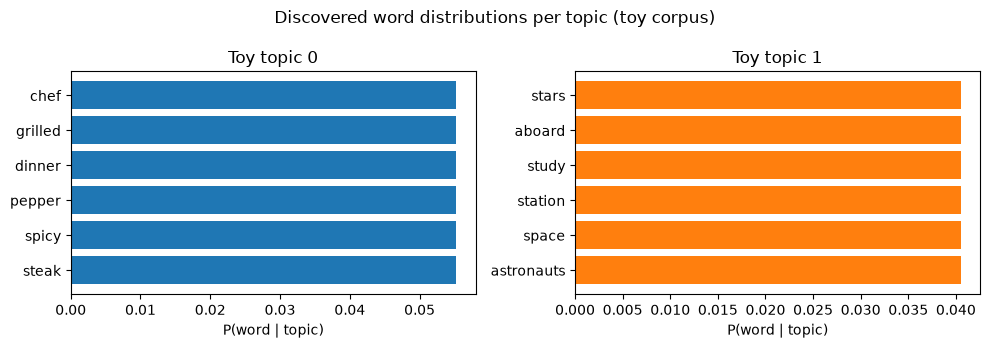

In [2]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for topic_id, ax in enumerate(axes):
    top_words = toy_lda.show_topic(topic_id, topn=6)
    words, probs = zip(*top_words)
    ax.barh(words[::-1], probs[::-1], color=f"C{topic_id}")
    ax.set_title(f"Toy topic {topic_id}")
    ax.set_xlabel("P(word | topic)")
fig.suptitle("Discovered word distributions per topic (toy corpus)")
fig.tight_layout()
plt.show()



## 5. Implementation: real LDA on real news articles

### 5.1 Loading the data

We use **AG News** (Zhang, Zhao & LeCun, 2015), a real, well-known news
classification dataset of ~127,600 articles pulled from over 2,000 news
sources, labeled into 4 categories: **World, Sports, Business, Sci/Tech**.
We'll use the first 3,000 training articles.

Crucially: we will **not** use the label column while training LDA — LDA
is unsupervised and never sees it. We only keep the labels aside so that,
*after* discovering topics blind, we can honestly check whether they line
up with real categories a human already agrees on. This is a convenience
this tutorial has that a genuinely unlabeled corpus would not — real
unsupervised workflows don't get this sanity check.


In [3]:

from datasets import load_dataset

ds = load_dataset("fancyzhx/ag_news", split="train[:3000]")
label_names = ds.features["label"].names
print(f"Loaded {len(ds)} articles")
print("Categories:", label_names)
print()
print("Example article:")
print(ds[0]["text"])
print("True label:", label_names[ds[0]["label"]])


Loaded 3000 articles
Categories: ['World', 'Sports', 'Business', 'Sci/Tech']

Example article:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
True label: Business



### 5.2 Preprocessing

We reuse the preprocessing techniques from this domain's tokenization
tutorial: lowercase, tokenize, drop stopwords and non-alphabetic tokens,
and lemmatize so that inflected forms (`companies` / `company`) collapse
to the same token — this matters a lot for LDA, since it counts raw word
co-occurrence, and splitting `company`/`companies` into two separate
vocabulary entries would dilute the signal for both.


In [4]:

import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = re.sub(r"[^A-Za-z\s]", " ", text.lower())
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return tokens

texts = [preprocess(doc) for doc in ds["text"]]
true_labels = ds["label"]

print("Before:", ds[0]["text"][:120])
print("After: ", texts[0])
print(f"\nAverage tokens per document after preprocessing: "
      f"{sum(len(t) for t in texts) / len(texts):.1f}")


Before: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics,
After:  ['wall', 'bear', 'claw', 'back', 'black', 'reuters', 'reuters', 'short', 'seller', 'wall', 'street', 'dwindling', 'band', 'ultra', 'cynic', 'seeing', 'green']

Average tokens per document after preprocessing: 25.7



### 5.3 Building the dictionary and bag-of-words corpus

`gensim.corpora.Dictionary` maps every distinct token to an integer ID.
We filter out extremely rare words (noise — appear in fewer than 5
documents) and extremely common words (appear in more than 50% of
documents, i.e. so common they carry no topic-discriminating signal) —
the bag-of-words equivalent of the stopword filtering already applied.


In [5]:

from gensim import corpora

dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below=5, no_above=0.5)
bow_corpus = [dictionary.doc2bow(doc) for doc in texts]

print(f"Vocabulary size after filtering: {len(dictionary)}")
print(f"Example document as bag-of-words (id, count): {bow_corpus[0][:10]}")


Vocabulary size after filtering: 2763
Example document as bag-of-words (id, count): [(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 2), (6, 1), (7, 1), (8, 1), (9, 2)]



### 5.4 Training LDA with the known category count (K=4)

We first train with $K=4$ topics, matching the number of known AG News
categories — a convenience we have *because* this dataset happens to come
with ground truth. `alpha='auto'` and `eta='auto'` let `gensim` learn the
Dirichlet concentration parameters from the data rather than us guessing
them (see §3.2).


In [6]:

from gensim.models import LdaModel

NUM_TOPICS = 4
lda_model = LdaModel(
    corpus=bow_corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=42,
    passes=10,
    alpha="auto",
    eta="auto",
)

for topic_id in range(NUM_TOPICS):
    top_words = lda_model.show_topic(topic_id, topn=10)
    print(f"Topic {topic_id}: " + ", ".join(w for w, _ in top_words))


Topic 0: new, microsoft, security, service, window, company, system, update, said, software
Topic 1: tuesday, said, two, reuters, british, new, year, five, leader, first
Topic 2: price, reuters, google, oil, new, said, stock, wednesday, share, inc
Topic 3: reuters, athens, olympic, profit, tuesday, game, olympics, gold, first, wednesday



### 5.5 Choosing the number of topics without ground truth: coherence score

In a genuinely unlabeled setting you would not know that 4 is "the right"
number of topics. The standard practitioner tool for this is **topic
coherence**: a measure of how semantically related a topic's top words are
to *each other*, computed purely from word co-occurrence statistics in the
corpus — no labels required. We use the **$C_v$ coherence measure**
(Röder, Both & Hinneburg, 2015), the most widely used variant, via
`gensim.models.CoherenceModel`. Higher is better (more internally
consistent topics).

Let's compute coherence for $K=4$ (matching the known category count) and
$K=8$ (a plausible alternative a practitioner might also try), and report
which one actually scores higher.


In [7]:

from gensim.models import CoherenceModel

coherence_scores = {}
models_by_k = {4: lda_model}

for k in (4, 8):
    if k not in models_by_k:
        models_by_k[k] = LdaModel(
            corpus=bow_corpus, id2word=dictionary, num_topics=k,
            random_state=42, passes=10, alpha="auto", eta="auto",
        )
    cm = CoherenceModel(model=models_by_k[k], texts=texts,
                         dictionary=dictionary, coherence="c_v")
    coherence_scores[k] = cm.get_coherence()

for k, score in coherence_scores.items():
    print(f"K={k}: C_v coherence = {score:.4f}")

best_k = max(coherence_scores, key=coherence_scores.get)
print(f"\nHigher coherence: K={best_k}")


K=4: C_v coherence = 0.3668
K=8: C_v coherence = 0.3671

Higher coherence: K=8



We'll continue the rest of the analysis with the $K=4$ model, since it
matches the dataset's real category count and lets us do the honest
ground-truth comparison below — but note the coherence result above as
the real, principled way you'd choose $K$ in the fully unsupervised case
where no such comparison is possible.

### 5.6 Visualizing discovered topics: top words per topic


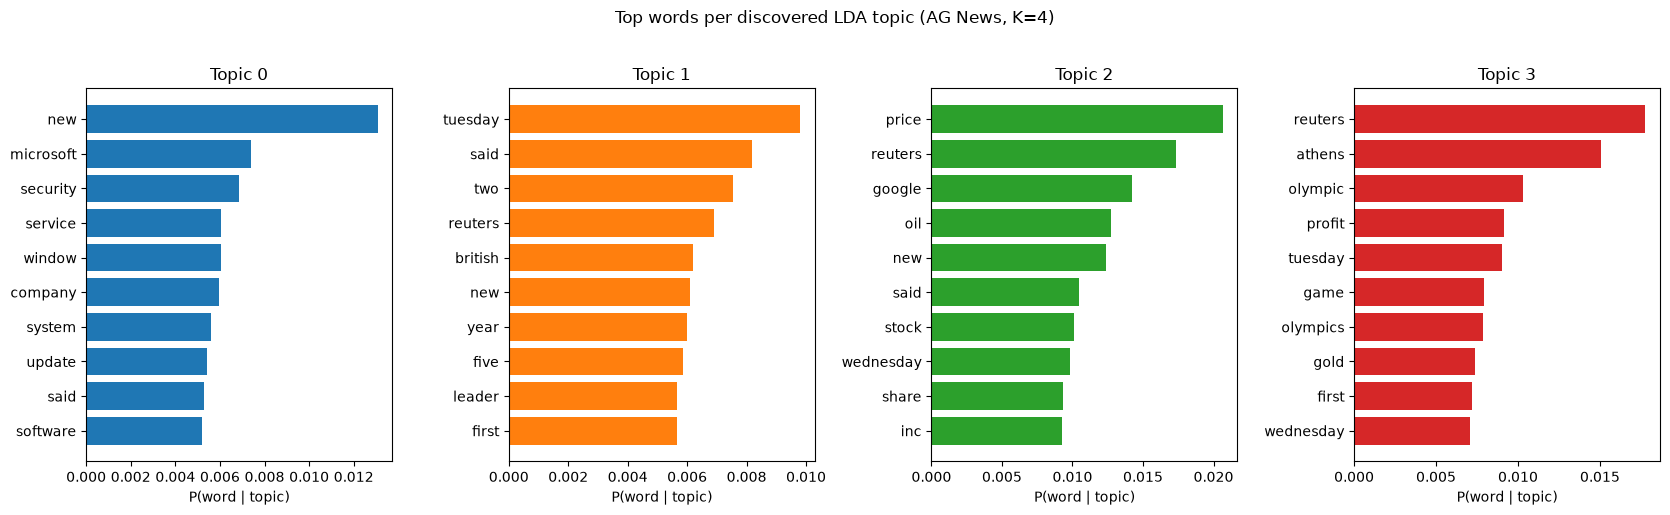

In [8]:

fig, axes = plt.subplots(1, NUM_TOPICS, figsize=(4.2 * NUM_TOPICS, 5))
for topic_id, ax in enumerate(axes):
    top_words = lda_model.show_topic(topic_id, topn=10)
    words, probs = zip(*top_words)
    ax.barh(words[::-1], probs[::-1], color=f"C{topic_id}")
    ax.set_title(f"Topic {topic_id}")
    ax.set_xlabel("P(word | topic)")
fig.suptitle("Top words per discovered LDA topic (AG News, K=4)", y=1.02)
fig.tight_layout()
plt.show()



### 5.7 The honest validation: discovered topics vs. real categories

For each article we take its **dominant topic** — the topic with the
highest probability in that document's inferred $\theta_d$ — and
cross-tabulate it against the article's real AG News category label. LDA
never saw the labels during training; this is purely a post-hoc check of
whether the *unsupervised* structure it found lines up with a labeling
scheme humans already agree on.


In [9]:

import numpy as np
import pandas as pd

dominant_topics = []
for bow in bow_corpus:
    topic_dist = lda_model.get_document_topics(bow, minimum_probability=0)
    dominant = max(topic_dist, key=lambda x: x[1])[0]
    dominant_topics.append(dominant)

alignment = pd.crosstab(
    pd.Series([label_names[l] for l in true_labels], name="True category"),
    pd.Series([f"Topic {t}" for t in dominant_topics], name="Discovered topic"),
)
alignment


Discovered topic,Topic 0,Topic 1,Topic 2,Topic 3
True category,,,,
Business,122,20,428,134
Sci/Tech,642,55,176,110
Sports,62,161,9,348
World,117,235,207,174


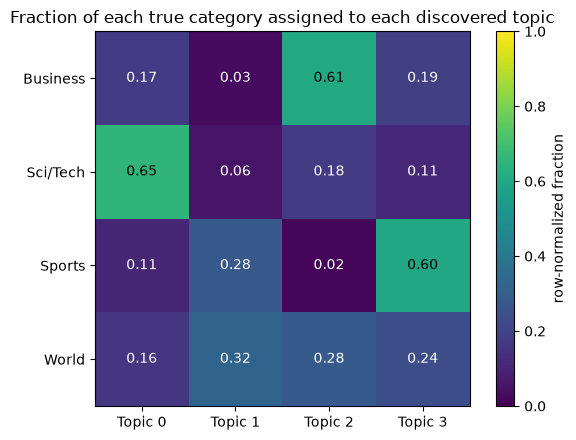

In [10]:

row_normalized = alignment.div(alignment.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(6, 4.5))
im = ax.imshow(row_normalized.values, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(row_normalized.columns)))
ax.set_xticklabels(row_normalized.columns)
ax.set_yticks(range(len(row_normalized.index)))
ax.set_yticklabels(row_normalized.index)
for i in range(row_normalized.shape[0]):
    for j in range(row_normalized.shape[1]):
        ax.text(j, i, f"{row_normalized.values[i, j]:.2f}",
                ha="center", va="center",
                color="white" if row_normalized.values[i, j] < 0.5 else "black")
ax.set_title("Fraction of each true category assigned to each discovered topic")
fig.colorbar(im, ax=ax, label="row-normalized fraction")
fig.tight_layout()
plt.show()



Read this row by row: each row is a true category, and the columns show
what fraction of *that category's* articles had each discovered topic as
their dominant one. If LDA's topics mapped perfectly onto the 4 real
categories, each row would have one entry near 1.0 and the rest near 0.
In practice, report whatever the numbers above actually show — some
categories (often **Sports**, since it has a very distinctive vocabulary:
`game`, `team`, `season`, `win`) tend to align cleanly with a single
discovered topic, while others (particularly **World** and **Business**,
which both contain heavy amounts of politics/economy vocabulary, or
**Sci/Tech**, which straddles business-technology-science reporting) often
smear across multiple topics or get absorbed into a topic dominated by a
different category. This is the expected, honest outcome of an
unsupervised method compared against a human-defined labeling scheme it
was never shown — not a bug in the code.



## 6. Use cases

- **Exploratory analysis of large unlabeled document collections** — "what
  is even in this dataset" is often the *first* step before deciding
  whether a supervised task is even well-posed, e.g. skimming a large
  research-paper archive (arXiv, PubMed) to see what subfields it contains
  before building a classifier for them.
- **Customer feedback / review mining** — a company with tens of thousands
  of unlabeled support tickets or product reviews can use LDA to discover
  recurring complaint/praise themes (shipping, pricing, quality, support
  responsiveness) without manually reading and tagging each one first.
- **Content organization and recommendation** — grouping articles, emails,
  or documents by discovered theme to power "more like this" recommendation
  or automatic folder/tag suggestions.
- **A precursor step to supervised learning** — topics discovered by LDA
  are sometimes used *as features* feeding into a downstream supervised
  classifier, or to help a human decide what label taxonomy would even
  make sense for a new dataset.



## 7. Limitations & debates

- **No guarantee topics are human-interpretable.** LDA topics are just
  probability distributions over words fitted to maximize a likelihood —
  nothing in the objective forces a topic to correspond to a category a
  human would recognize or name. Some discovered topics are cleanly
  interpretable (our toy example, and often "Sports" above); others are a
  grab-bag of loosely-related words, and this is a matter of luck/data more
  than something you can always fix by tuning hyperparameters.
- **The number of topics $K$ is a hyperparameter you must choose, usually
  without ground truth.** We used the AG News's known 4-category count as
  a convenient shortcut in §5.4-5.5 — a genuinely unlabeled corpus offers
  no such shortcut, and you're left with coherence-score sweeps (§5.5),
  domain knowledge, or trial-and-error inspection of top words. Different
  reasonable choices of $K$ can produce meaningfully different, equally
  "valid" topic decompositions of the same corpus.
- **Coherence score is a proxy, not ground truth.** A high $C_v$ score
  means a topic's top words tend to co-occur near each other in the
  corpus — it does not guarantee the topic maps onto any real-world
  category, and different coherence variants ($C_v$, $C_{uci}$, $C_{umass}$)
  can disagree with each other on the same model (Röder et al., 2015).
- **Bag-of-words generative process, no word order.** LDA treats each
  document as an unordered multiset of words — "dog bites man" and "man
  bites dog" produce identical bag-of-words input and are statistically
  indistinguishable to LDA. This is the exact same fundamental limitation
  flagged in this domain's bag-of-words-and-TF-IDF tutorial, and it means
  LDA can never use syntax, negation, or word order as a signal for topic
  discovery.
- **Neural topic models are increasingly preferred in practice.**
  **BERTopic** (Grootendorst, 2022) replaces LDA's Dirichlet generative
  story with a pipeline of contextual sentence embeddings (from a
  transformer), dimensionality reduction, and clustering, then extracts
  representative words per cluster with a class-based TF-IDF weighting.
  This sidesteps the bag-of-words assumption entirely (embeddings capture
  context and word order to some extent) and often produces more coherent
  topics on modern benchmarks, at the cost of needing a pretrained
  transformer and more compute than LDA's lightweight variational updates.
  We don't implement BERTopic here, but it's worth knowing LDA is not the
  final word on topic modeling — it's the classical, interpretable,
  cheap-to-fit baseline that neural approaches are actively displacing in
  many production settings.
- **Sensitive to preprocessing choices.** Stopword lists, lemmatization,
  and the `no_below`/`no_above` dictionary filters in §5.3 all materially
  change which words survive into the vocabulary LDA can even use — a
  different preprocessing pipeline on the same raw corpus can produce
  visibly different topics, which is an underappreciated reproducibility
  hazard in practice.



## 8. References

- Blei, D.M., Ng, A.Y., Jordan, M.I. (2003). *Latent Dirichlet Allocation.*
  Journal of Machine Learning Research, 3, 993-1022.
- Hofmann, T. (1999). *Probabilistic Latent Semantic Indexing.* SIGIR 1999
  — LDA's direct predecessor (pLSI), which LDA extends with a proper
  generative/Bayesian treatment of the per-document topic mixture.
- Hoffman, M., Blei, D.M., Bach, F. (2010). *Online Learning for Latent
  Dirichlet Allocation.* NeurIPS 2010 — the online variational Bayes
  algorithm `gensim.models.LdaModel` implements.
- Röder, M., Both, A., Hinneburg, A. (2015). *Exploring the Space of Topic
  Coherence Measures.* WSDM 2015.
- Grootendorst, M. (2022). *BERTopic: Neural topic modeling with a
  class-based TF-IDF procedure.* arXiv:2203.05794.
- Zhang, X., Zhao, J., LeCun, Y. (2015). *Character-level Convolutional
  Networks for Text Classification.* NeurIPS 2015 — source of the AG News
  dataset.
- `gensim` documentation: `gensim.models.LdaModel`,
  `gensim.models.CoherenceModel`, `gensim.corpora.Dictionary`.
